<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_4_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Part 4
## Multiclass Evaluation: Fetal Health Diagnosis

Author: Brad Sheese

---

## Introduction: Beyond Binary

In Parts 1-3, we built a complete binary classification toolkit on the South German Credit dataset: confusion matrices, precision/recall, F1-scores, ROC curves, and threshold tuning. All of that work assumed exactly two outcomes (default or not).

But many critical real-world problems involve **three or more distinct categories**. In medicine, for example, we often need to distinguish between **Normal**, **Suspect**, and **Pathological** states. This notebook generalizes the evaluation tools from Parts 1-3 to the multiclass setting, using a new clinical dataset.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Explain how multiclass classification extends binary classification (softmax probabilities, per-class metrics).
2. Interpret a 3x3 multiclass confusion matrix and identify specific types of misclassification.
3. Show how a simple model can fall into the **imbalance trap** on multiclass data, and how a stronger model recovers.
4. Explain the difference between **Macro**, **Weighted**, and **Micro** averaging strategies in a classification report.
5. Understand how **sample weighting** can help models pay more attention to minority classes.

## Section 1: The Fetal Health Dataset

The **Cardiotocography (CTG)** dataset contains measurements from fetal heart rate and uterine contraction monitoring during pregnancy. Based on these measurements, each record is classified into one of three fetal health categories:

1. **Normal** (healthy)
2. **Suspect** (requires closer monitoring)
3. **Pathological** (immediate medical intervention needed)

The dataset has 35 numeric features (labeled `V1` through `V35` in this version). These correspond to clinical measurements such as baseline fetal heart rate, number of accelerations and decelerations, short-term and long-term variability, and histogram statistics of the heart rate signal.

Let's load the data and examine the most important characteristic of multiclass problems: the **class distribution**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.utils import compute_sample_weight

sns.set_theme(style="whitegrid")

# Load the Cardiotocography dataset (3-class version of Fetal Health)
# Original class labels: 1 = Normal, 2 = Suspect, 3 = Pathological
data = fetch_openml(data_id=1560, as_frame=True, parser="auto")
df = data.frame

X = df.drop(columns=["Class"])

# XGBoost's multiclass objective requires zero-indexed integer labels (0, 1, 2, ...)
y = df["Class"].astype(int) - 1
target_names = ["Normal", "Suspect", "Pathological"]

print(f"Dataset shape: {X.shape[0]} samples, {X.shape[1]} features")
print(f"\nFirst 5 rows:")
display(X.head())

Dataset shape: 2126 samples, 35 features

First 5 rows:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35
0,23,240,357,120,120,0,0,0,73,0.5,...,0,0,0,0,0,0,0,0,1,0
1,45,5,632,132,132,4,0,4,17,2.1,...,0,0,0,0,0,1,0,0,0,0
2,45,177,779,133,133,2,0,5,16,2.1,...,0,0,0,0,0,1,0,0,0,0
3,45,411,1192,134,134,2,0,6,16,2.4,...,0,0,0,0,0,1,0,0,0,0
4,45,533,1147,132,132,4,0,5,16,2.4,...,0,1,0,0,0,0,0,0,0,0


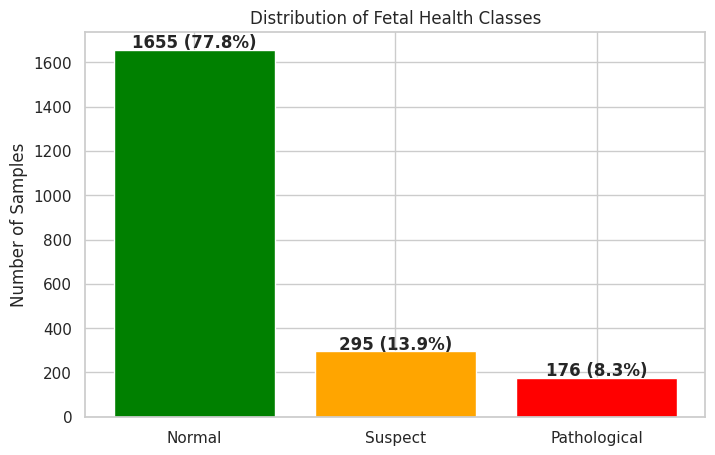

Naive baseline (always predict Normal): 77.8% accuracy


In [2]:
# Examine class distribution
counts = np.bincount(y)
naive_baseline = counts[0] / len(y)

plt.figure(figsize=(8, 5))
plt.bar(target_names, counts, color=["green", "orange", "red"])
plt.title("Distribution of Fetal Health Classes")
plt.ylabel("Number of Samples")
for i, count in enumerate(counts):
    plt.text(i, count + 10, f"{count} ({count/len(y):.1%})", ha="center", fontweight="bold")
plt.show()

print(f"Naive baseline (always predict Normal): {naive_baseline:.1%} accuracy")

### The Imbalance Trap

Notice that **77.8%** of the samples are 'Normal'. This is a classic **imbalanced** dataset.

A model that simply predicted 'Normal' for every single patient would achieve nearly **78% accuracy** while failing to catch 100% of the life-threatening 'Pathological' cases. The 'Pathological' class makes up only **8.3%** of the data, so the model has very few examples to learn from.

This is the same accuracy paradox we saw in Part 1 with the credit dataset, but now it is even more dangerous: there are three classes, and the rarest one is the most critical.

## Section 2: How Multiclass Classification Works

In **binary** classification, the model outputs a single probability (e.g., P(Default) = 0.73), and we apply a threshold to decide the class.

In **multiclass** classification, the model outputs a probability for *each* class. For a 3-class problem, the output might look like:

| P(Normal) | P(Suspect) | P(Pathological) |
|-----------|------------|------------------|
| 0.85      | 0.10       | 0.05             |

The predicted class is whichever has the **highest probability**. In this example, the model predicts 'Normal'.

XGBoost achieves this using a function called **softmax**, which converts raw model outputs into a valid probability distribution (all values between 0 and 1, summing to 1.0). This is what the `objective="multi:softprob"` parameter does.

Another common strategy is **One-vs-Rest (OvR)**: train a separate binary classifier for each class (Normal vs. Not-Normal, Suspect vs. Not-Suspect, etc.) and combine them. Softmax and OvR are the two main approaches; XGBoost uses softmax by default for multiclass problems.

In [3]:
# Stratified split preserves class proportions in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=16, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")
print(f"\nTest set class distribution:")
test_counts = np.bincount(y_test)
for i, name in enumerate(target_names):
    print(f"  {name:>12}: {test_counts[i]:>3} ({test_counts[i]/len(y_test):.1%})")

Training set: 1700 samples
Test set:     426 samples

Test set class distribution:
        Normal: 332 (77.9%)
       Suspect:  59 (13.8%)
  Pathological:  35 (8.2%)


## Section 3: A Simple Model Falls Into the Trap

To see the imbalance trap in action, let's start with a deliberately simple model: a **Decision Tree with only 2 levels of depth**. This model can only make a handful of splits, so it has limited capacity to distinguish between classes. When capacity is limited, models tend to focus on the majority class because that is where they can reduce the most errors.

Let's see what happens.

Decision Tree Accuracy: 93.4%
Naive Baseline:         77.8%
Improvement over baseline: +15.6%


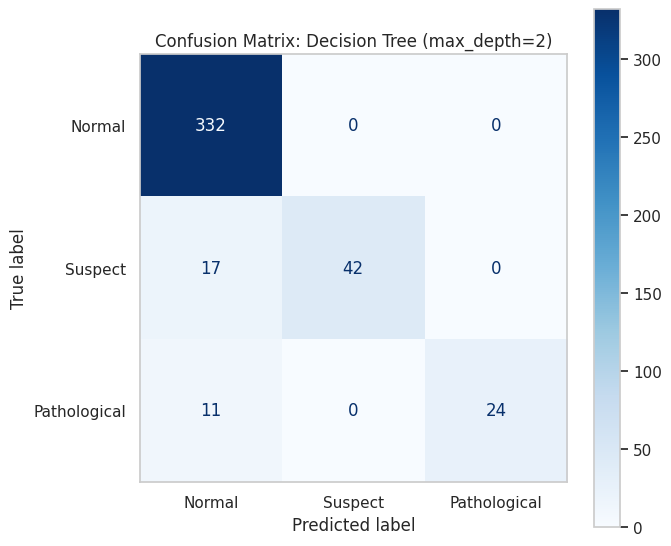

In [4]:
# A shallow Decision Tree: limited capacity, prone to the imbalance trap
naive_model = DecisionTreeClassifier(max_depth=2, random_state=16)
naive_model.fit(X_train, y_train)
y_pred_naive = naive_model.predict(X_test)

naive_acc = accuracy_score(y_test, y_pred_naive)
print(f"Decision Tree Accuracy: {naive_acc:.1%}")
print(f"Naive Baseline:         {naive_baseline:.1%}")
print(f"Improvement over baseline: {naive_acc - naive_baseline:+.1%}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_naive,
    display_labels=target_names,
    cmap="Blues",
    ax=ax
)
ax.set_title("Confusion Matrix: Decision Tree (max_depth=2)")
ax.grid(False)
plt.tight_layout()
plt.show()

### Reading the 3x3 Confusion Matrix

Just like in Part 2, the **diagonal** contains correct predictions and the **off-diagonal** cells contain errors. But now we have a richer picture of *which* classes are being confused with *which*.

Look at the results above:

- **Normal (top row):** The model gets all 332 Normal cases correct. No surprise; this is the majority class.
- **Suspect (middle row):** The model correctly identifies 42 of 59 Suspect cases, but misclassifies 17 as Normal.
- **Pathological (bottom row):** The model correctly identifies only 24 of 35 Pathological cases. **11 Pathological cases are predicted as Normal.** These are critically ill fetuses that the model says are healthy.

### Not All Errors Are Equal

In a clinical setting, the cost of errors depends on their direction:

1. **False Alarm:** Predicting 'Suspect' or 'Pathological' when the fetus is actually 'Normal'. This leads to unnecessary stress and testing, but the patient is safe.
2. **Fatal Miss:** Predicting 'Normal' when the fetus is actually 'Pathological'. This is the most dangerous error because a critical condition goes untreated.

The model achieves **93% accuracy**, which sounds excellent. But it misses **31% of Pathological cases** by labeling them as Normal. In a hospital using this model, nearly 1 in 3 critically ill fetuses would be sent home.

## Section 4: XGBoost to the Rescue

Now let's train a properly configured **XGBoost** model. As we learned in Part 1, XGBoost builds an ensemble of many decision trees sequentially, where each new tree corrects the errors of the previous ones. This gives it far more capacity than a single shallow tree, especially for learning patterns in minority classes.

In [5]:
# Train XGBoost with reasonable hyperparameters
xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=16,
    eval_metric="mlogloss"
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy:       {xgb_acc:.1%}")
print(f"Decision Tree Accuracy: {naive_acc:.1%}")
print(f"Naive Baseline:         {naive_baseline:.1%}")

XGBoost Accuracy:       98.8%
Decision Tree Accuracy: 93.4%
Naive Baseline:         77.8%


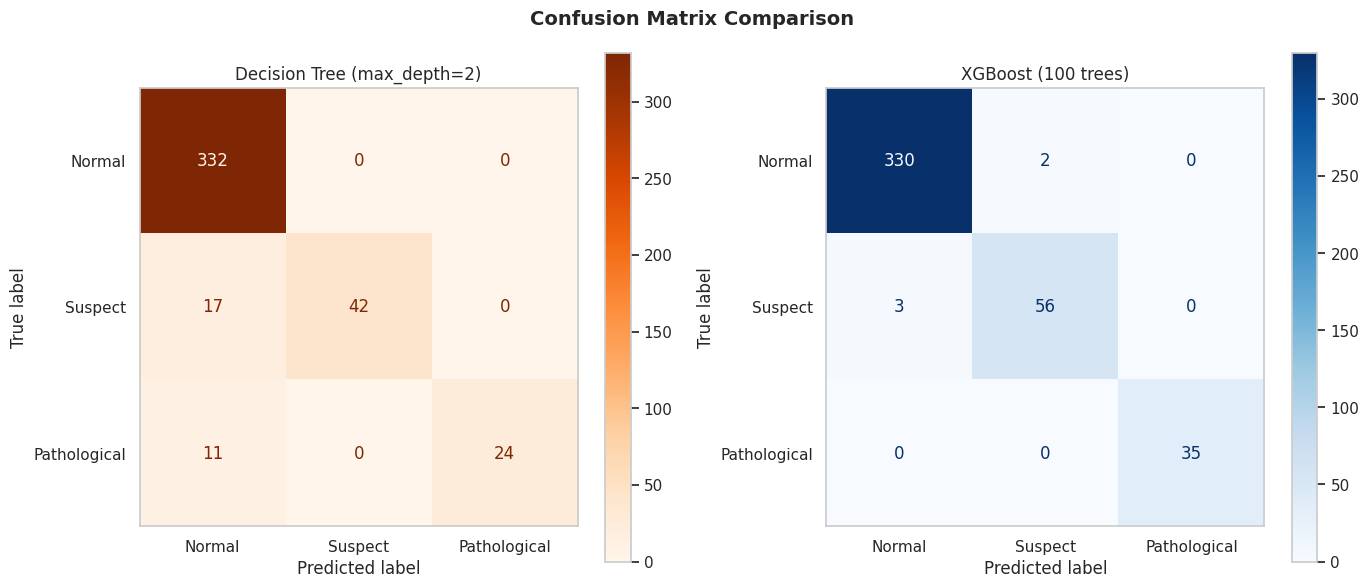

In [6]:
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_naive,
    display_labels=target_names,
    cmap="Oranges",
    ax=ax1
)
ax1.set_title("Decision Tree (max_depth=2)")
ax1.grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=target_names,
    cmap="Blues",
    ax=ax2
)
ax2.set_title("XGBoost (100 trees)")
ax2.grid(False)

plt.suptitle("Confusion Matrix Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Comparing the Two Models

Look at the **Pathological row** (bottom row) in both matrices:

- **Decision Tree:** 24 correct, **11 Fatal Misses** (predicted Normal when actually Pathological).
- **XGBoost:** 35 correct, **0 Fatal Misses**.

Now look at the **Suspect row** (middle row):

- **Decision Tree:** 42 correct, 17 missed (all predicted as Normal).
- **XGBoost:** 56 correct, only 3 missed.

XGBoost's ensemble approach, with 100 sequential trees each correcting the last, gives it the capacity to learn subtle patterns that distinguish the minority classes. The shallow Decision Tree simply doesn't have enough depth to capture these differences.

## Section 5: Per-Class Metrics in Multiclass

In Part 2, we learned that **precision** and **recall** answer different questions:
- **Precision:** "When the model predicts this class, how often is it right?"
- **Recall:** "Of all actual cases of this class, how many did the model catch?"

In binary classification, these metrics are defined for the single "positive" class. In multiclass, we compute them **separately for each class**. For example:

- **Recall for Pathological** = (Pathological cases correctly predicted) / (Total actual Pathological cases). This tells us: "Of all truly Pathological fetuses, what fraction did the model identify?"
- **Precision for Suspect** = (Suspect cases correctly predicted) / (Total predictions labeled Suspect). This tells us: "When the model flags a fetus as Suspect, how often is it actually Suspect?"

Let's print the classification reports for both models to see these per-class metrics.

In [7]:
print("=" * 60)
print("Classification Report: Decision Tree (max_depth=2)")
print("=" * 60)
print(classification_report(y_test, y_pred_naive,
                            target_names=target_names,
                            zero_division=0))

print("=" * 60)
print("Classification Report: XGBoost")
print("=" * 60)
print(classification_report(y_test, y_pred_xgb,
                            target_names=target_names))

Classification Report: Decision Tree (max_depth=2)
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96       332
     Suspect       1.00      0.71      0.83        59
Pathological       1.00      0.69      0.81        35

    accuracy                           0.93       426
   macro avg       0.97      0.80      0.87       426
weighted avg       0.94      0.93      0.93       426

Classification Report: XGBoost
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       332
     Suspect       0.97      0.95      0.96        59
Pathological       1.00      1.00      1.00        35

    accuracy                           0.99       426
   macro avg       0.99      0.98      0.98       426
weighted avg       0.99      0.99      0.99       426



### Walking Through the Decision Tree Report

Focus on the Decision Tree report:

| Class | Precision | Recall | F1 | Support |
|-------|-----------|--------|-----|--------|
| Normal | 0.92 | 1.00 | 0.96 | 332 |
| Suspect | 1.00 | 0.71 | 0.83 | 59 |
| Pathological | 1.00 | 0.69 | 0.81 | 35 |

Key observations:

- **Normal recall = 1.00:** The model catches every single Normal case. No surprise; the tree is biased toward the majority class.
- **Pathological recall = 0.69:** The model only catches 69% of Pathological cases. The other 31% are **Fatal Misses**.
- **Pathological precision = 1.00:** When the model *does* predict Pathological, it is always correct. But it's overly cautious; it would rather miss a Pathological case than falsely flag one.

Compare this to XGBoost, where recall is above 0.93 for every class. The ensemble has enough capacity to catch minority class patterns without sacrificing precision.

## Section 6: The Averaging Problem (Macro vs. Weighted)

When we have per-class F1-scores, how do we summarize them into a single number? There are three strategies, and they tell **very different stories** when classes are imbalanced.

In [8]:
# Let's compute the averages manually for the Decision Tree
# to see exactly how they work.

from sklearn.metrics import f1_score

# Per-class F1 scores for the Decision Tree
f1_per_class = f1_score(y_test, y_pred_naive, average=None, zero_division=0)

print("Per-class F1 scores (Decision Tree):")
for name, score in zip(target_names, f1_per_class):
    print(f"  {name:>12}: {score:.2f}")

# Macro average: simple mean (treats all classes equally)
macro_f1 = f1_per_class.mean()
print(f"\nMacro F1 = ({f1_per_class[0]:.2f} + {f1_per_class[1]:.2f} + {f1_per_class[2]:.2f}) / 3 = {macro_f1:.2f}")

# Weighted average: weighted by support (number of samples per class)
supports = np.bincount(y_test)
weighted_f1 = np.average(f1_per_class, weights=supports)
print(f"\nWeighted F1 = ({supports[0]}*{f1_per_class[0]:.2f} + {supports[1]}*{f1_per_class[1]:.2f} + {supports[2]}*{f1_per_class[2]:.2f}) / {supports.sum()}")
print(f"            = {weighted_f1:.2f}")

print(f"\nAccuracy    = {naive_acc:.2f}")
print(f"\nGap: Weighted F1 ({weighted_f1:.2f}) vs Macro F1 ({macro_f1:.2f}) = {weighted_f1 - macro_f1:+.2f}")

Per-class F1 scores (Decision Tree):
        Normal: 0.96
       Suspect: 0.83
  Pathological: 0.81

Macro F1 = (0.96 + 0.83 + 0.81) / 3 = 0.87

Weighted F1 = (332*0.96 + 59*0.83 + 35*0.81) / 426
            = 0.93

Accuracy    = 0.93

Gap: Weighted F1 (0.93) vs Macro F1 (0.87) = +0.06


### Which Average Should You Use?

The gap between Weighted F1 and Macro F1 is the **signature of the imbalance trap**. For the Decision Tree:

- **Weighted F1** is high because the 332 Normal samples (with F1=0.96) dominate the calculation. The 35 Pathological samples barely register.
- **Macro F1** is lower because it treats Normal and Pathological as equally important. The poor Pathological score drags the average down.

Here is when to use each:

1.  **Macro Avg:** Treats all classes as equally important. Calculates F1 for each class separately, then takes the simple arithmetic mean.
    *   *When to use:* When you care about performance on minority classes. If the model is terrible at the rare 'Pathological' class, the Macro Avg will be low, even if 'Normal' is perfect.

2.  **Weighted Avg:** Weights each class's score by its "support" (the number of samples in that class).
    *   *When to use:* When you want to reflect the model's performance on the overall population. But beware: it can mask poor performance on rare classes.

3.  **Accuracy (equivalent to Micro Avg):** Counts total correct predictions divided by total predictions.
    *   *Note:* Scikit-Learn's classification report labels this simply as `accuracy` because, for standard multiclass problems, Micro Precision, Micro Recall, and Micro F1 all evaluate to the same number: overall accuracy.

**Rule of Thumb:** In imbalanced multiclass problems, **Macro F1** is usually your best indicator of how well the model is performing across all classes.

## Section 7: Addressing Imbalance with Sample Weights

We've seen that XGBoost handles this dataset's imbalance well thanks to its ensemble power. But what if you're using a simpler model, or the imbalance is more extreme?

One general strategy is **sample weighting**. The idea: during training, give higher weight to samples from rare classes, so the model pays more attention to them. Scikit-learn provides `compute_sample_weight('balanced', y)` which automatically calculates weights inversely proportional to class frequency.

In Part 1, we used `scale_pos_weight` in XGBoost for binary imbalance. `sample_weight` is the more general version that works with *any* scikit-learn model and *any* number of classes.

In [9]:
# Compute balanced sample weights
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Show what the weights look like
print("Sample weights by class:")
for i, name in enumerate(target_names):
    mask = (y_train == i)
    print(f"  {name:>12}: weight = {weights[mask][0]:.2f} (applied to {mask.sum()} training samples)")

print("\nRare classes get higher weights, so their errors cost more during training.")

Sample weights by class:
        Normal: weight = 0.43 (applied to 1323 training samples)
       Suspect: weight = 2.40 (applied to 236 training samples)
  Pathological: weight = 4.02 (applied to 141 training samples)

Rare classes get higher weights, so their errors cost more during training.


In [10]:
# Retrain the Decision Tree with balanced sample weights
weighted_model = DecisionTreeClassifier(max_depth=3, random_state=16)
weighted_model.fit(X_train, y_train, sample_weight=weights)
y_pred_weighted = weighted_model.predict(X_test)

print("Classification Report: Decision Tree (max_depth=3, balanced weights)")
print(classification_report(y_test, y_pred_weighted,
                            target_names=target_names,
                            zero_division=0))

# Compare to the original unweighted tree
print("Comparison of Macro F1:")
macro_naive = f1_score(y_test, y_pred_naive, average='macro', zero_division=0)
macro_weighted_tree = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
macro_xgb = f1_score(y_test, y_pred_xgb, average='macro')
print(f"  Decision Tree (depth=2, no weights): {macro_naive:.2f}")
print(f"  Decision Tree (depth=3, balanced):   {macro_weighted_tree:.2f}")
print(f"  XGBoost (100 trees):                 {macro_xgb:.2f}")

Classification Report: Decision Tree (max_depth=3, balanced weights)
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.98       332
     Suspect       1.00      0.71      0.83        59
Pathological       1.00      1.00      1.00        35

    accuracy                           0.96       426
   macro avg       0.98      0.90      0.94       426
weighted avg       0.96      0.96      0.96       426

Comparison of Macro F1:
  Decision Tree (depth=2, no weights): 0.87
  Decision Tree (depth=3, balanced):   0.94
  XGBoost (100 trees):                 0.98


### Key Takeaway

Sample weighting is one tool in a larger toolkit for handling class imbalance. Other strategies include:

- **Oversampling** minority classes (e.g., SMOTE) to create synthetic examples
- **Undersampling** the majority class to reduce its dominance
- **Cost-sensitive learning** where different misclassifications have different penalties

For this particular dataset, XGBoost's ensemble approach handles imbalance well on its own. But on harder problems with more extreme imbalance (such as fraud detection, where the positive class may be <1%), sample weighting becomes essential. You will practice this technique in the exercises.

## Conclusion

We have moved from binary classification to the more complex world of multiclass evaluation. Here is what we learned:

1. **Multiclass models output probabilities for each class** using softmax (or One-vs-Rest). The predicted class is whichever has the highest probability.

2. **The confusion matrix scales** from 2x2 to NxN. This lets us see specifically which classes are being confused with which (e.g., 'Pathological' misclassified as 'Normal').

3. **Not all errors are equal.** In clinical settings, a 'Fatal Miss' (predicting Normal when actually Pathological) is far more dangerous than a 'False Alarm' (predicting Pathological when actually Normal).

4. **Simple models fall into the imbalance trap.** A shallow Decision Tree achieved 93% accuracy but missed 31% of Pathological cases. XGBoost's ensemble approach recovered nearly all of them.

5. **Macro F1 is your friend for imbalanced data.** The gap between Weighted F1 and Macro F1 reveals whether the model is genuinely performing well or just riding the majority class.

6. **Sample weighting** is one technique to force models to pay more attention to rare classes during training.

### Practical Checklist for Multiclass Projects

When building a multiclass model:
1. Always check the class distribution first.
2. Compare model accuracy against the naive baseline (majority class %).
3. Inspect the confusion matrix for dangerous misclassifications.
4. Report Macro F1 alongside accuracy; the gap between them tells the imbalance story.
5. Consider sample weighting when minority class performance matters.